### Pyrpl in Notebook

In [ ]:
import sys

import matplotlib.pyplot as plt

import pyrpl
import logging
import io
import numpy as np
import os

# Create a string IO object to capture logs
log_stream = io.StringIO()
# Create a handler that writes to the StringIO object
stream_handler = logging.StreamHandler(log_stream)
stream_handler.setLevel(logging.DEBUG)  # Capture all messages
# Format the log messages
formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
stream_handler.setFormatter(formatter)

# Get the pyrpl logger and add our handler
logging.basicConfig(level=logging.DEBUG)
logger = logging.getLogger('pyrpl')
logger.addHandler(stream_handler)

# Define hostname
HOSTNAME = "10.203.129.28"

p = pyrpl.Pyrpl(config="config_name",
                hostname=HOSTNAME,
                reloadfpga=True,
                reloadserver=True)
rp = p.redpitaya  # shortcut for the the redpitaya handler


# Now you can retrieve the log contents at any time
def show_logs():
    return log_stream.getvalue()

### Testing

In [ ]:
hk = rp.hk
hk.configure_pin('P1', direction="output", source="source", invert=False)
hk.expansion_P1 = True

In [ ]:
rp.iq0.frequency = 5e3

In [ ]:
rp.hk.configure_pin("P7", direction="output", source="source", invert=False)
rp.hk.expansion_P7 = True

In [ ]:
rp.iq0.frequency = 5e3
rp.iq0.on = True
rp.iq0._read(0x140)

In [ ]:
# Check what input is currently selected for IQ0
input_select = rp.iq0._read(0x0)
print(f"IQ0 input select: {input_select} (should be 10 for ADC1)")

# Check the module status
status = rp.iq0._read(0x100)
print(f"IQ0 status register: 0x{status:x}")

# Read the current output signal value
current_signal = rp.iq0._read(0x10)
print(f"IQ0 current output signal: {current_signal}")

# Set up the IQ module
rp.iq0.input = 'in1'  # or 'adc1'
rp.iq0.frequency = 1e6  # Set a frequency
rp.iq0.bandwidth = 1e3  # Set bandwidth

# Configure NA parameters
rp.iq0._write(0x130, 1000)  # na_averages
rp.iq0._write(0x134, 100)   # na_sleepcycles

# Trigger NA by writing frequency (this starts averaging)
rp.iq0._write(0x108, int(1e6 * 2**32 / 125e6))  # Write frequency to trigger

# Wait a bit for averaging
import time
time.sleep(0.1)

# Now read NA data
na_data = rp.iq0._read(0x140)
print(f"NA data register 0x140: 0x{na_data:08x}")
print(f"Averaging active: {bool(na_data >> 31)}")
print(f"I sum (lower 31 bits): {na_data & 0x7FFFFFFF}")

### ODMR Scan Testing

In [ ]:
rp.hk.configure_pin("P1", direction="output", source="module", invert=False)
rp.hk.configure_pin("P7", direction="output", source="module", invert=True)
rp.iq0.frequency = 16e3

rp.asg0.output_direct = "out1"
rp.asg1.output_direct = "out2"
rp.asg0.trigger_source = 'immediately'
rp.asg1.trigger_source = 'immediately'

rp.fgen3.gen_enable = True
rp.fgen3.output_to_dsp_enable_o = True

rp.fgen3.frequency0 = 20e6
rp.fgen3.fm_enable0 = True
rp.fgen3.fm_deviation_khz0 = 500
rp.fgen3.amplitude_a0 = 0.05

In [ ]:

rp.scan.dwell_time = 0.001
rp.scan.num_steps = 1000
rp.scan.trigger_length = 0.2e-3
rp.scan.run_sweep(timeout=60)

In [ ]:
data = rp.scan.get_data()
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(len(data)),data, linewidth=1)
# increase axis number font size
plt.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel("Scan Index", fontsize=20)
ax.set_ylabel("ADC Data", fontsize=20)
plt.tight_layout()
plt.savefig("testing_new.pdf")
plt.show()


In [ ]:
data = rp.scan.get_data()
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.scatter(np.arange(len(data)),data, s=1)
plt.show()

In [ ]:
data = rp.scan.get_data()
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.scatter(np.arange(len(data)),data, s=1)
plt.show()

In [ ]:
rp.asg0.output_direct = "out1"
rp.asg1.output_direct = "out2"
rp.asg0.trigger_source = 'immediately'
rp.asg1.trigger_source = 'immediately'
rp.asg0.frequency = 1e6
rp.asg1.frequenyc = 1e6

rp.asg0.amplitude = 0.1
rp.asg1.amplitude = 0.1



In [ ]:
hk = rp.hk

In [ ]:
hk.configure_pin('P7', direction="output", source="module")

In [ ]:
hk.expansion_P7 = True

In [ ]:
rp.scan.dwell_time = 1
rp.scan.num_steps = 5
rp.scan.trigger_length = 1

In [ ]:
rp.scan.start()

In [ ]:
rp.scan.busy

---

In [ ]:
rp.ams.dac3 = 0.9

In [ ]:
rp.ams.set_pwm_frequency(3, 50)

In [ ]:
hk.led = 0x00

In [ ]:
rp.iq0.frequency = 2

In [ ]:
locals()['expansion_P' + str(2) + '_output']

In [ ]:
locals()

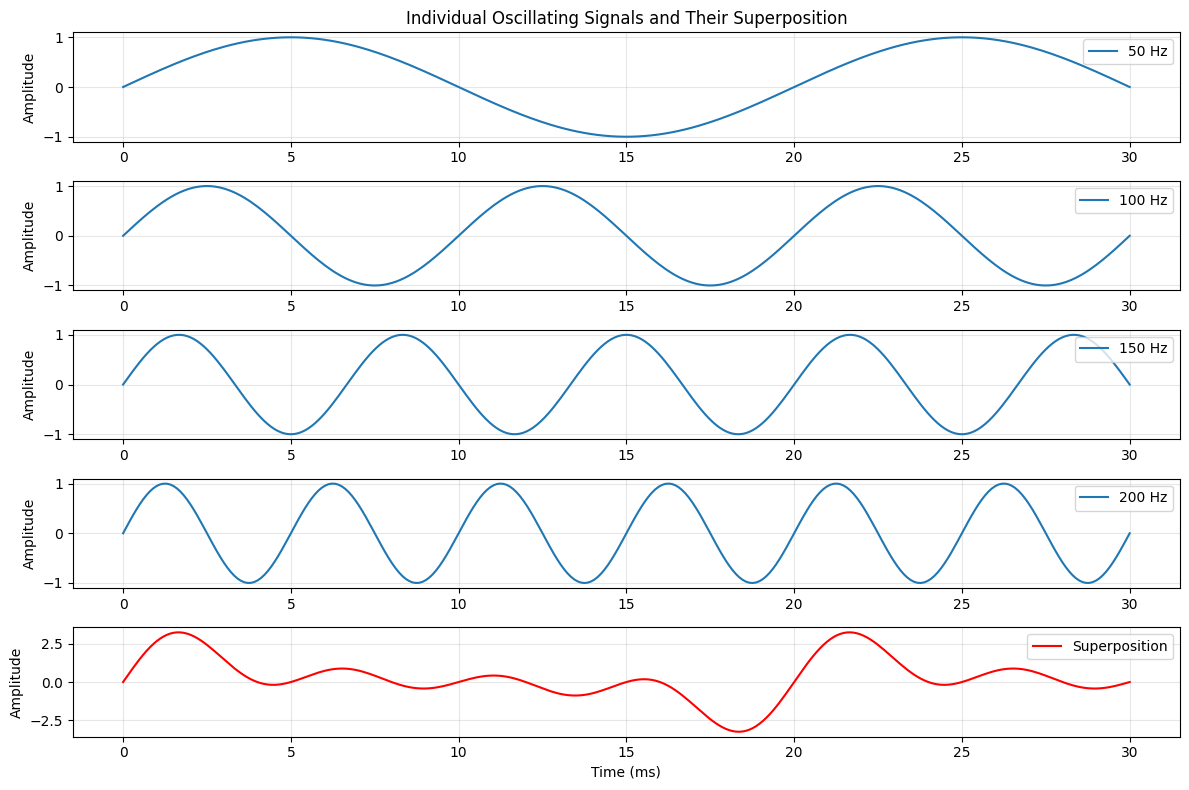

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Time parameters
duration = 0.03  # 30 ms in seconds
sampling_rate = 10000  # High sampling rate for smooth curves
t = np.linspace(0, duration, int(sampling_rate * duration))

# Frequencies in Hz
frequencies = [50, 100, 150, 200]

# Generate individual signals
signals = []
for freq in frequencies:
    signal = np.sin(2 * np.pi * freq * t)
    signals.append(signal)

# Create superposition (sum of all signals)
superposition = np.sum(signals, axis=0)

# Create the plot
plt.figure(figsize=(12, 8))

# Plot individual signals
for i, (freq, signal) in enumerate(zip(frequencies, signals)):
    plt.subplot(len(frequencies) + 1, 1, i + 1)
    plt.plot(t * 1000, signal, label=f'{freq} Hz')  # Convert time to ms
    plt.ylabel('Amplitude')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    if i == 0:
        plt.title('Individual Oscillating Signals and Their Superposition')

# Plot superposition
plt.subplot(len(frequencies) + 1, 1, len(frequencies) + 1)
plt.plot(t * 1000, superposition, color='red', linewidth=1.5, label='Superposition')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()